# Chapter 5: Positional Encodings

Attention is permutation-invariant: without additional information, the model sees a *bag of tokens*
rather than an ordered sequence. Positional encodings inject sequence-order information into
the token representations before the first transformer layer.

This chapter covers four strategies:

| Strategy | Type | Parameters | Length generalisation |
|----------|------|------------|-----------------------|
| Sinusoidal | Fixed, absolute | 0 | Yes (formula extends) |
| Learned | Trainable, absolute | `max_seq_len × d_model` | No (table is finite) |
| RoPE | Fixed, relative (applied to Q/K) | 0 | Yes (frequencies extrapolate) |
| Relative Position Bias | Trainable, relative (added to logits) | `num_buckets × num_heads` | Partial (bucket saturation) |

In [1]:
import matplotlib.pyplot as plt
import torch

from transformer_book_lab.sinusoidal_pe import SinusoidalPositionalEncoding
from transformer_book_lab.learned_pe import LearnedPositionalEncoding
from transformer_book_lab.rope import build_rope_cache, apply_rope
from transformer_book_lab.relative_position_bias import RelativePositionBias

D_MODEL  = 64
SEQ_LEN  = 50
BATCH    = 1

## 1. Sinusoidal Positional Encoding

The original "Attention Is All You Need" (Vaswani et al., 2017) encoding uses sine and cosine
functions at geometrically-spaced frequencies:

```
PE(pos, 2i)   = sin( pos / 10000^(2i / d_model) )
PE(pos, 2i+1) = cos( pos / 10000^(2i / d_model) )
```

Each position gets a unique fingerprint across dimensions. Low-index dimensions oscillate fast
(short wavelength); high-index dimensions oscillate slowly (long wavelength). The pattern is
analogous to binary counting in a mixed-radix number system.

Because the encoding is formula-based, it extends to any sequence length without retraining.

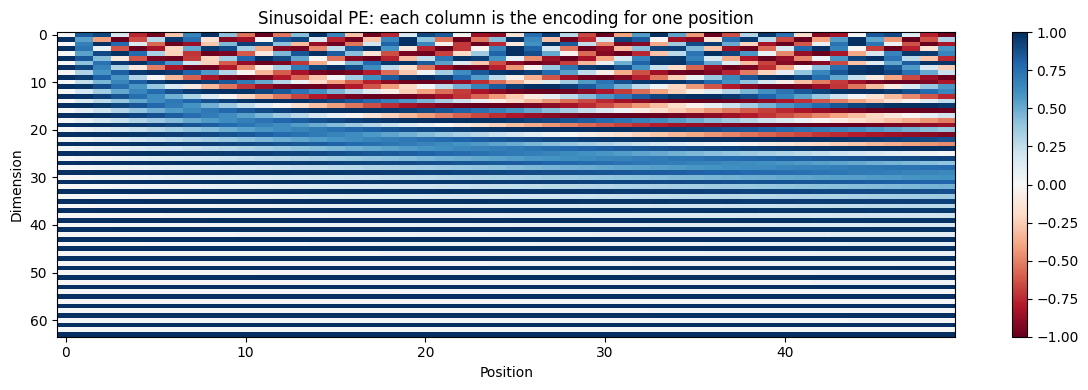

PE buffer shape: torch.Size([50, 64])
Trainable parameters: 0


In [2]:
spe = SinusoidalPositionalEncoding(d_model=D_MODEL, max_seq_len=SEQ_LEN)

# spe.pe: (SEQ_LEN, D_MODEL)
pe_matrix = spe.pe.numpy()   # detach — it is a buffer, not a parameter

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pe_matrix.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("Position")
ax.set_ylabel("Dimension")
ax.set_title("Sinusoidal PE: each column is the encoding for one position")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print(f"PE buffer shape: {spe.pe.shape}")
print(f"Trainable parameters: {sum(p.numel() for p in spe.parameters())}")

## 2. Learned Positional Encoding

BERT and GPT-2 use a trainable `nn.Embedding(max_seq_len, d_model)` table instead of a formula.
Each position index maps to a learned vector. The model can discover whatever positional
representation is most useful for the task — at the cost of being unable to generalise beyond
`max_seq_len` at inference time.

The random initialisation means the encoding is meaningless before training. After training,
adjacent position vectors tend to be more similar than distant ones (the model learns smoothness).

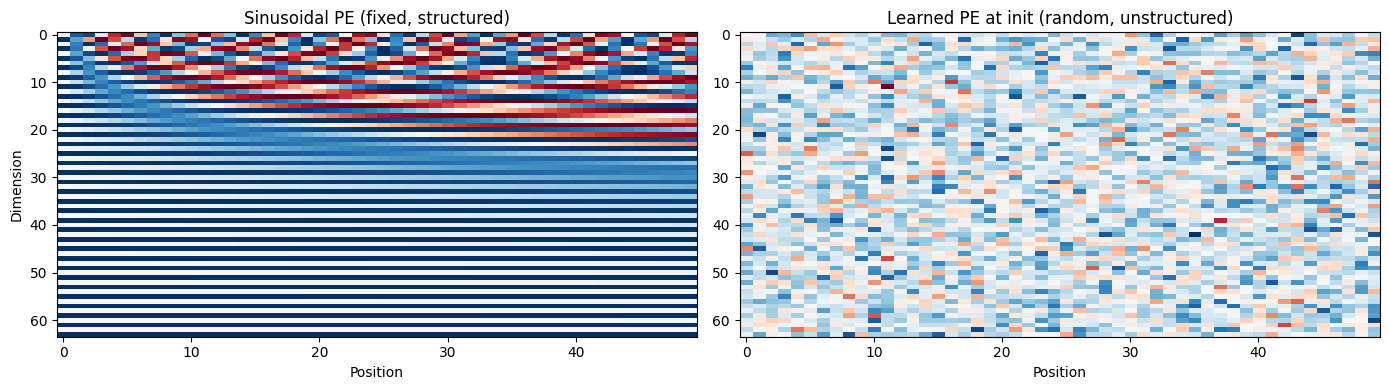

Learned PE parameter count: 3200  (50 × 64)


In [3]:
lpe = LearnedPositionalEncoding(d_model=D_MODEL, max_seq_len=SEQ_LEN)

# Weight matrix at random init: (SEQ_LEN, D_MODEL)
learned_matrix = lpe.embedding.weight.detach().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].imshow(pe_matrix.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
axes[0].set_title("Sinusoidal PE (fixed, structured)")
axes[0].set_xlabel("Position")
axes[0].set_ylabel("Dimension")

axes[1].imshow(learned_matrix.T, aspect="auto", cmap="RdBu")
axes[1].set_title("Learned PE at init (random, unstructured)")
axes[1].set_xlabel("Position")

plt.tight_layout()
plt.show()

print(f"Learned PE parameter count: {sum(p.numel() for p in lpe.parameters())}  ({SEQ_LEN} × {D_MODEL})")

## 3. Rotary Positional Encoding (RoPE)

RoPE (Su et al., 2021) encodes position by *rotating* the query and key vectors before the
dot product. Rotating both Q and K by their respective position angles means the dot product
`Q_m · K_n` depends on the *relative* displacement `m - n`, not the absolute positions.

The rotation is applied to adjacent pairs of dimensions using a 2D rotation matrix:

```
[x, y] → [x·cos(θ) - y·sin(θ),  x·sin(θ) + y·cos(θ)]
```

Because it is a rotation (isometry), it preserves vector norms — important for stable attention.
RoPE is parameter-free and used in LLaMA, Mistral, GPT-NeoX, and Falcon.

RoPE cache shapes — cos: torch.Size([50, 16]), sin: torch.Size([50, 16])
Rotated Q shape: torch.Size([1, 4, 50, 32])
Norm preserved: True


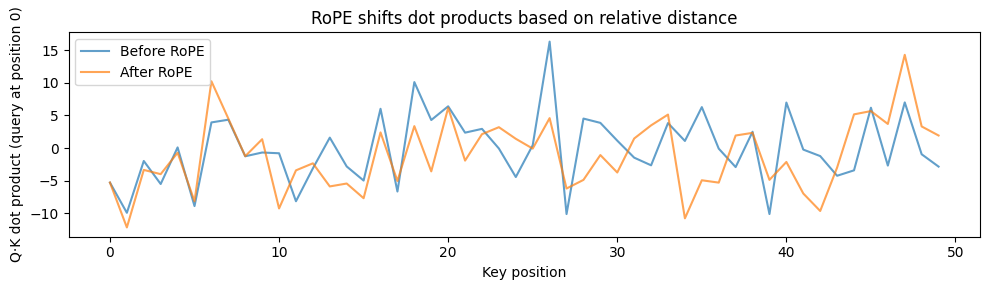

In [4]:
HEAD_DIM = 32
NUM_HEADS = 4

cos, sin = build_rope_cache(seq_len=SEQ_LEN, head_dim=HEAD_DIM)
print(f"RoPE cache shapes — cos: {cos.shape}, sin: {sin.shape}")

torch.manual_seed(0)
q = torch.randn(BATCH, NUM_HEADS, SEQ_LEN, HEAD_DIM)
k = torch.randn(BATCH, NUM_HEADS, SEQ_LEN, HEAD_DIM)

q_rot, k_rot = apply_rope(q, k, cos, sin)
print(f"Rotated Q shape: {q_rot.shape}")
print(f"Norm preserved: {torch.allclose(q.norm(dim=-1), q_rot.norm(dim=-1), atol=1e-5)}")

# Demonstrate relative-position sensitivity: dot products before and after rotation
# For a fixed query at position 0, dot with keys at various positions
dots_before = (q[:, :, 0:1, :] * k).sum(-1)[0, 0]            # (SEQ_LEN,)
dots_after  = (q_rot[:, :, 0:1, :] * k_rot).sum(-1)[0, 0]    # (SEQ_LEN,)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dots_before.detach().numpy(), label="Before RoPE", alpha=0.7)
ax.plot(dots_after.detach().numpy(),  label="After RoPE",  alpha=0.7)
ax.set_xlabel("Key position")
ax.set_ylabel("Q·K dot product (query at position 0)")
ax.set_title("RoPE shifts dot products based on relative distance")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Relative Position Bias

T5 (Raffel et al., 2020) uses a different relative encoding: a learned scalar bias added to
the attention logits for each head based on the relative distance between query and key.

Distances are mapped to a fixed number of *buckets* using a log-spaced scheme:
- Small distances get their own exact bucket (linear spacing).
- Large distances share buckets (logarithmic spacing, so many distances map to the same bucket).

This means the model has high resolution for nearby positions and lower resolution for distant
ones — matching the intuition that nearby context matters most. The bias matrix is added to
the attention scores before the softmax, shaping which positions each head attends to.

Bias shape: torch.Size([4, 50, 50])


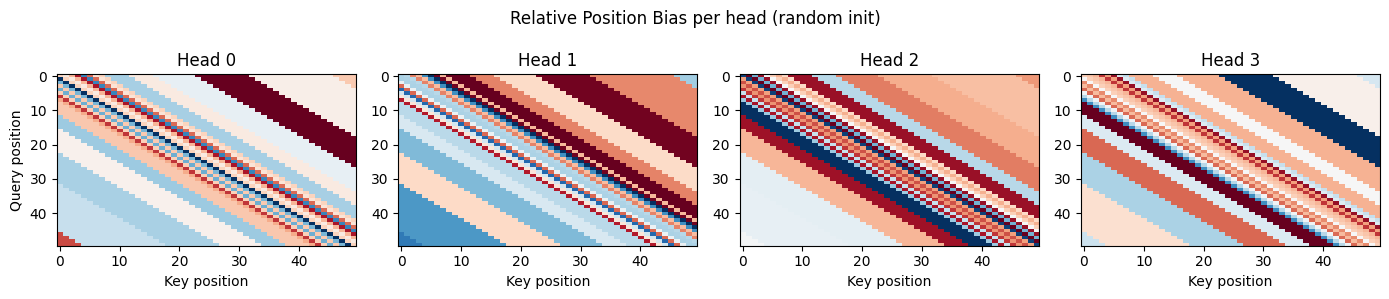

Diagonal entries are uniform per head (distance 0 always maps to the same bucket).


In [5]:
rpb = RelativePositionBias(num_heads=NUM_HEADS, num_buckets=32, max_distance=128)
bias = rpb(SEQ_LEN)   # (num_heads, SEQ_LEN, SEQ_LEN)
print(f"Bias shape: {bias.shape}")

fig, axes = plt.subplots(1, NUM_HEADS, figsize=(14, 3))
for h in range(NUM_HEADS):
    im = axes[h].imshow(bias[h].detach().numpy(), aspect="auto", cmap="RdBu")
    axes[h].set_title(f"Head {h}")
    axes[h].set_xlabel("Key position")
    if h == 0:
        axes[h].set_ylabel("Query position")
plt.suptitle("Relative Position Bias per head (random init)")
plt.tight_layout()
plt.show()

# Confirm diagonal (distance 0) is uniform per head
for h in range(NUM_HEADS):
    diag = bias[h].diagonal().detach()
    assert diag.eq(diag[0]).all()
print("Diagonal entries are uniform per head (distance 0 always maps to the same bucket).")

## 5. Comparison: Fixed vs Learned, Absolute vs Relative

| Property | Sinusoidal | Learned | RoPE | Rel. Bias |
|----------|-----------|---------|------|-----------|
| Parameters | 0 | `max_len × d_model` | 0 | `buckets × heads` |
| Absolute / Relative | Absolute | Absolute | Relative | Relative |
| Generalises beyond training length | Yes | No | Yes | Partial |
| Applied where | Input embeddings | Input embeddings | Q/K inside attention | Attention logits |
| Used in | Original Transformer | BERT, GPT-2 | LLaMA, Mistral, Falcon | T5, mT5 |

**Absolute** encodings add position information to the token vector before the first layer;
every layer then propagates it through residual connections.

**Relative** encodings act inside each attention layer: the position signal is recomputed
at every layer, which gives the model finer-grained control over how position affects each head.

## Key Takeaways

- Attention alone is permutation-invariant; positional encodings are the mechanism that
  breaks this symmetry and lets the model reason about token order.

- **Sinusoidal PE** is parameter-free, deterministic, and generalises to any length.
  Its regular geometric structure can sometimes be exploited by the model.

- **Learned PE** is more flexible but strictly limited to the training length.
  Passing a longer sequence at inference time raises `IndexError` — a hard failure.

- **RoPE** encodes position in the *angle* between Q and K vectors. It is parameter-free,
  norm-preserving (rotation is an isometry), and the current default in open-weight LLMs.

- **Relative Position Bias** uses learned scalars per distance bucket. Log-spacing gives
  high resolution for nearby tokens and low resolution for distant ones.

- The trend in modern architectures: move from absolute to relative, and from per-layer
  addition to Q/K rotation, because relative encodings are more robust to length shifts.

## Final Exercise

**Length generalisation test**

The key practical difference between sinusoidal and learned PE is what happens when you
pass a sequence *longer than the training length*.

1. Instantiate a `SinusoidalPositionalEncoding(d_model=32, max_seq_len=32)` and a
   `LearnedPositionalEncoding(d_model=32, max_seq_len=32)`.
2. Create a dummy input tensor `x` of shape `(1, 64, 32)` (twice the training length).
3. Pass `x` through the sinusoidal encoder. Does it succeed?
4. Pass `x` through the learned encoder. What happens?
5. Explain in one sentence why the sinusoidal encoder succeeds while the learned encoder fails,
   and under what conditions the sinusoidal generalisation might still degrade in practice.

In [6]:
# Your solution here
